# Treasury market according to Flow of Funds Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from dbnomics import fetch_series

In [54]:
# Paramétrage des styles utilisés par matplotlib
plt.style.use('default')
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

### Premiers graphiques

Code :
* Le .Q à la fin c'est pour donnée Quaterly (et.A pour annuelle).
* FL : pour les niveaux
* Secteur c'est les deux chiffres suivants
* 30611 c'est pour l'instrument (Treasuries)
* 05 pour les "computed series"

Code pour le moment :
* FL143061105.Q : Nonfinancial business (S11) 
* FL153061105.Q : Households and nonprofit organizations (S14+S15)
* FL263061105.Q : Rest of the World (S2)*
* FL383061105.Q : Domestic nonfinancial sectors
* FL403061105.Q : Government-sponsored enterprises (GSEs)
* FL473061105.Q : Credit Unions
* FL513061105.Q : Property-casualty insurance companies*
* FL523061105.Q : Insurance companies (S128)
* FL533061105.Q : Closed-end and exchange-traded funds
* FL543061105.Q : Life insurance companies*
* FL573061105.Q : Private pension funds
* FL583061105.Q : Insurance companies and pension funds (S128+S129) 
* FL593061105.Q : Pension funds (S129)
* FL603061105.Q : Other financial intermediaries except insurance companies, pension funds, financial auxiliaries and captive financial institutions and money lenders (S125)
* FL803061105.Q : Other financial intermediaries except insurance companies and pension funds (S125+S126+S127) 
* FL633061105.Q : Money market funds (S123)
* FL653061105.Q : Mutual funds*
* FL663061105.Q : Security brokers and dealers (S127 ?)
* FL693061105.Q : Non-MMF investment funds (S124)
* FL703061105.Q : Private depository institutions (S122)
* FL713061125.Q : Monetary authority (S121)
* FL783061105.Q : Private depository institutions and money market funds (S122+S123)
* FL793061105.Q : Domestic financial sectors (S12)
* FL893061105.Q : All sectors


\* petite incertitude pcq y'a trois séries possibles sur dbnmics, probablement une erreur

In [3]:
import dbnomics
import pandas as pd
import matplotlib.pyplot as plt

# Sélection des séries (sans double comptage)
codes = {
    "Nonfinancial business (S11)": "FL143061105.Q",
    "Rest of World (S2)": "FL263061105.Q",
    "Households and non-profit organizations (S14+S15)": "FL153061105.Q",
    "Monetary authority (S121)": "FL713061125.Q",
    "Private Depository Institutions (S122)": "FL703061105.Q",
    "Money Market Funds (S123)": "FL633061105.Q",
    "Mutual Funds (S124)": "FL653061105.Q",
    "Other financial intermediaries except insurance companies and pension funds (S125+S126+S127)" : "FL803061105.Q",
    "Insurance companies (S128)": "FL523061105.Q",
    "Pension Funds (S129)": "FL593061105.Q",
    "Security brokers and dealers": "FL663061105.Q",
    "Closed-end and exchange-traded funds": "FL533061105.Q"
}

# Télécharger et assembler les séries
dfs = []
for label, code in codes.items():
    data = dbnomics.fetch_series(f"FED/Z1/{code}")
    df_temp = data[['period', 'value']].dropna()
    df_temp['period'] = pd.PeriodIndex(df_temp['period'], freq='Q').to_timestamp()
    df_temp = df_temp.set_index('period').rename(columns={'value': label})
    dfs.append(df_temp)

df = pd.concat(dfs, axis=1)

# Télécharger la série "All sectors"
all_sectors = dbnomics.fetch_series("FED/Z1/FL893061105.Q")
all_sectors = all_sectors[['period', 'value']].dropna()
all_sectors['period'] = pd.PeriodIndex(all_sectors['period'], freq='Q').to_timestamp()
all_sectors = all_sectors.set_index('period')['value']

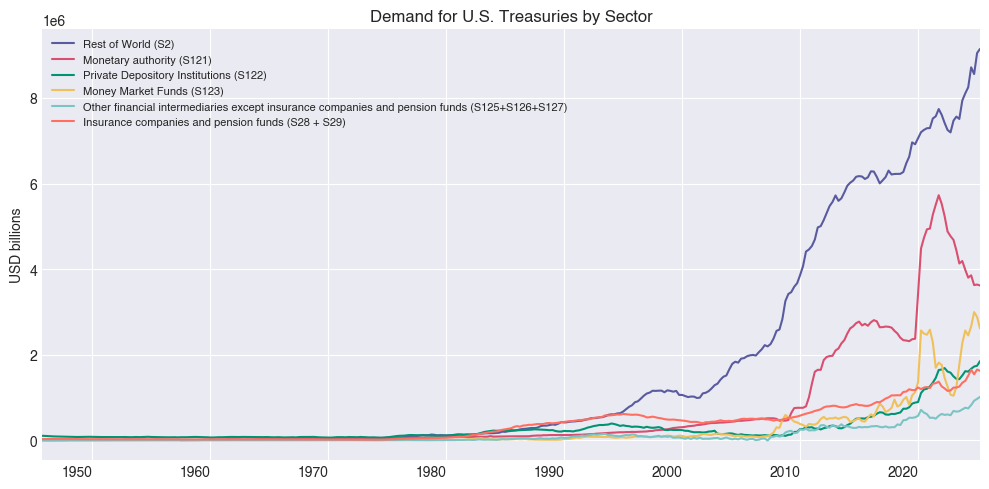

In [80]:
df1 = df.copy()
df1["Insurance companies and pension funds (S28 + S29)"] = df1["Insurance companies (S128)"] + df1["Pension Funds (S129)"]

df1 = df1.drop(columns=["Households and non-profit organizations (S14+S15)",
                        "Mutual Funds (S124)", "Nonfinancial business (S11)",
                        "Insurance companies (S128)",
                        "Pension Funds (S129)",
                        "Security brokers and dealers",
                        "Closed-end and exchange-traded funds"])
df1.index.name = None

#start_date = '1945-01-01'
#end_date = '1991-01-01'
#df1 = df1[(df.index >= start_date) & (df.index <= end_date)]

# Tracer
fig, ax = plt.subplots(figsize=(10, 5))
df1.plot(ax=ax)
ax.set_title("Demand for U.S. Treasuries by Sector")
ax.set_ylabel("USD billions")
#ax.set_yscale('log')
#ax.set_yscale('symlog', linthresh=10000)
ax.set_xmargin(0)
plt.xticks(rotation=0)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

/var/folders/my/3_9szq6j5z97dfcrfmtk4wq80000gn/T/ipykernel_18399/1060120625.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = list(plt.cm.get_cmap('Set1').colors[:6])


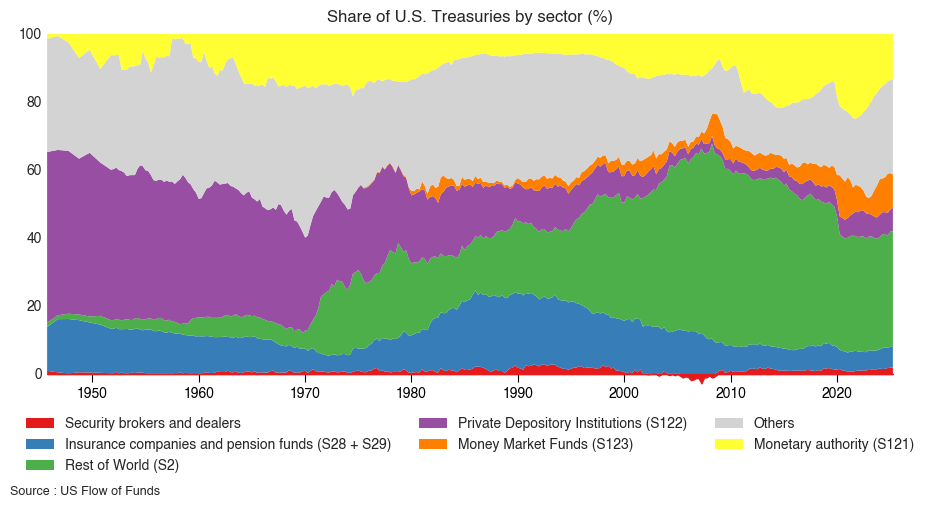

In [83]:
df_prop = df.div(all_sectors, axis=0)
df_prop = df_prop * 100
df_prop["Insurance companies and pension funds (S28 + S29)"] = df_prop["Insurance companies (S128)"] + df_prop["Pension Funds (S129)"]


# Sélection de quelques séries
selected = ["Security brokers and dealers",
            "Insurance companies and pension funds (S28 + S29)",
            "Rest of World (S2)",
            "Private Depository Institutions (S122)",
            "Money Market Funds (S123)",
            "Monetary authority (S121)",
            ]

neg = df_prop["Security brokers and dealers"].clip(upper=0)
pos = df_prop["Security brokers and dealers"].clip(lower=0)
df_prop["Security brokers and dealers"] = pos

# Calcul de la part "Others"
df_prop = df_prop[selected].copy()
df_prop["Others"] = 100 - df_prop.sum(axis=1)

selected.remove("Monetary authority (S121)")
selected.append("Others")
selected.append("Monetary authority (S121)")
df_prop = df_prop[selected]


colors = list(plt.cm.get_cmap('Set1').colors[:6])        
colors.append('lightgray')
colors[-1], colors[-2] = colors [-2], colors [-1]



# Tracé
fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(df_prop.index, df_prop.T, labels=df_prop.columns,colors=colors)
ax.set_xmargin(0)
ax.margins(y=0.01)
ax.set_facecolor('white')
ax.set_title("Share of U.S. Treasuries by sector (%)")
ax.fill_between(df_prop.index, neg, 0, color=colors[0])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)

# Forcer la spine du bas
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('black')
#ax.spines['bottom'].set_linewidth(1.0)

# Forcer les ticks vers l'extérieur et visibles
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', which='both', direction='out', length=6, colors='black', bottom=True, top=False)

# S'assurer que les labels sont visibles
ax.xaxis.set_tick_params(labelcolor='black')

plt.xticks(rotation=0)
fig.text(0.04, -0.0, "Source : US Flow of Funds", ha="left", fontsize=9)

plt.tight_layout()
plt.show()